# Part 1 - One Output

In [1]:
import numpy as np
from sklearn.metrics import accuracy_score

## Just doing the easiest one available right now

<figure style="text-align:center">
<img src="figures/basic-network.png" width="40%">
</figure>

In [2]:
def activation_function(x, deriv=False):
    """Activates the sleepy or computes the derivative"""
    sigmoid = 1 / (1+ np.exp(-x))
    if deriv:
        return sigmoid * (1 - sigmoid)
    return sigmoid

In [3]:
X = np.array(
    [
        [-1, -1],
        [-1, 1],
        [1, -1],
        [1, 1]
    ]
)

y = np.array([0, 1, 1, 0]).T

In [4]:
# set constants:
gamma = 0.005
n_input_nodes = 2
n_output_nodes = 1

# Define inputs
# each row is a sample and col a feature
X = np.array(
    [
        [-1, -1],
        [-1, 1],
        [1, -1],
        [1, 1]
    ]
)

y = np.array([[0, 1, 1, 0]]).T

# initialize weights
# have the initial weights have mean 0 and std 1
w0 = np.random.normal(loc=0, scale=1, size=(n_input_nodes, n_output_nodes))

epochs = int(1e4)

print(f"Initial weights:\n{w0}")
print("=" * 50)

for epoch in range(epochs):
    layer0 = X
    layer1 = activation_function(np.dot(layer0, w0))

    error = (layer1 - y)
    if epoch % 1000 == 0:
        print(f"Iter: {epoch} --- Error: {np.mean(np.abs(error)):.4f}")
    
    layer1_delta = error * activation_function(np.dot(layer0, w0), deriv=True)
    w0 -= gamma * np.dot(layer0.T, layer1_delta)

y_preds = np.rint(layer1).flatten()

print("=" * 50)
print("Raw Output after training:\n")
print(layer1)
print("Learned weights:\n")
print(w0)
print("-" * 50)
print(f"Thresholded result at 0.5:{y_preds}")
print(f"Accuracy: {accuracy_score(y, y_preds) * 100:.2f}%")

Initial weights:
[[1.69922416]
 [0.04164976]]
Iter: 0 --- Error: 0.5000
Iter: 1000 --- Error: 0.5000
Iter: 2000 --- Error: 0.5000
Iter: 3000 --- Error: 0.5000
Iter: 4000 --- Error: 0.5000
Iter: 5000 --- Error: 0.5000
Iter: 6000 --- Error: 0.5000
Iter: 7000 --- Error: 0.5000
Iter: 8000 --- Error: 0.5000
Iter: 9000 --- Error: 0.5000
Raw Output after training:

[[0.49999704]
 [0.49999736]
 [0.50000264]
 [0.50000296]]
Learned weights:

[[1.11886823e-05]
 [6.45147111e-07]]
--------------------------------------------------
Thresholded result at 0.5:[0. 0. 1. 1.]
Accuracy: 50.00%


Thanks, now I can see exactly what’s going on. Let’s analyze your code carefully.

---

### 1️⃣ Changing this to **gradient ascent**

Currently, your weight update is:

```python
w0 -= gamma * np.dot(layer0.T, layer1_delta)
```

* For **gradient ascent**, you would **add** instead of subtracting:

```python
w0 += gamma * np.dot(layer0.T, layer1_delta)
```

* Second, make sure your **error definition** matches your goal:

```python
error = (layer1 - y)  # currently assumes minimizing squared error
```

* If you are maximizing something (like a reward), the error term may need to be reversed:

```python
error = (y - layer1)
```

So the **two major changes** are:

1. Change `w0 -= ...` → `w0 += ...`
2. Possibly reverse the error term depending on the objective.

---

### 2️⃣ Why the results are likely inaccurate

Looking at your setup:

1. **No hidden layer** → you’re trying to learn XOR with a **single linear layer**.

   * XOR is **not linearly separable**, so a single layer cannot learn it correctly.
   * This is the main reason accuracy will **never reach 100%**.

2. **Bias term is missing**

   * Without bias, the network cannot shift the activation function to better fit the data.

3. **Activation function might not be appropriate**

   * You didn’t show `activation_function`, but for XOR you usually need **sigmoid or tanh in a hidden layer**, then another nonlinearity.

---

✅ **Summary**:

* **To convert to gradient ascent**: reverse the sign of weight updates and/or the error depending on the objective.
* **Reason for poor accuracy**: XOR is **not linearly separable**, your network has **no hidden layer**, and **no bias term**, so it can’t model the target function.

---

If you want, I can rewrite your code **with a proper hidden layer and bias** so it can learn XOR correctly. Do you want me to do that?


## The Bias Node

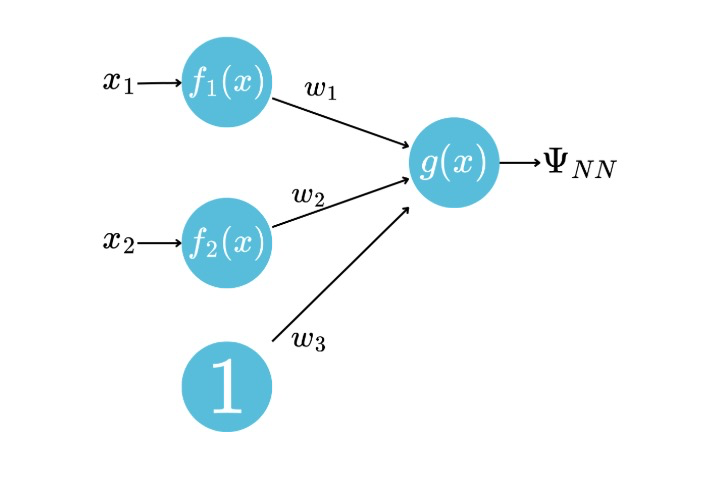

for np.insert:
X → your input array (shape (4, 2) for XOR)

0 → insert at column 0 (the first column)

bias → the value to insert (usually 1)

axis=1 → insert as a new column

In [5]:
# define our constants
gamma = 0.005
n_input_nodes = 3  # notice that we changed this
n_output_nodes = 1

bias = [1, 1, 1, 1] # These are not learnable in this case
# Notice that for X_biased, the first column will always just be 1, 1, 1, 1
X_biased = np.insert(X, 0, bias, axis=1)
X_biased

# Change thar targets based on the chosen Psi columns
y = np.array([[0, 1, 1, 0]]).T

w1 = np.random.normal(loc=0, scale=1, size=(n_input_nodes, n_output_nodes))
num_epochs = int(1e4)

print(f"Initial weights:\n{w1}")
print("=" * 50)

# training the network
for epoch in range(num_epochs):
    layer0 = X_biased
    layer1 = activation_function(np.dot(layer0, w1))

    error = layer1 - y
    if epoch % 1000 == 0:
        print(f"Iter: {epoch} --- Error: {np.mean(np.abs(error)):.4f}")
    
    layer1_delta = error * activation_function(np.dot(layer0, w1), deriv=True)
    w1 -= gamma * np.dot(layer0.T, layer1_delta)

y_preds = [1 if x > 0.5 else 0 for x in layer1]

print("=" * 50)
print("Raw Output after training:\n")
print(layer1)
print("Learned weights:\n")
print(w1)
print("-" * 50)
print(f"Thresholded result at 0.5:{y_preds}")
print(f"Accuracy: {accuracy_score(y, y_preds) * 100:.2f}%")
    

Initial weights:
[[-0.90840276]
 [-0.36251047]
 [-0.63073689]]
Iter: 0 --- Error: 0.5176
Iter: 1000 --- Error: 0.5001
Iter: 2000 --- Error: 0.5000
Iter: 3000 --- Error: 0.5000
Iter: 4000 --- Error: 0.5000
Iter: 5000 --- Error: 0.5000
Iter: 6000 --- Error: 0.5000
Iter: 7000 --- Error: 0.5000
Iter: 8000 --- Error: 0.5000
Iter: 9000 --- Error: 0.5000
Raw Output after training:

[[0.49999946]
 [0.49999781]
 [0.49999991]
 [0.49999825]]
Learned weights:

[[-4.56512667e-06]
 [ 8.91182003e-07]
 [-3.31129586e-06]]
--------------------------------------------------
Thresholded result at 0.5:[0, 0, 0, 0]
Accuracy: 50.00%


## Hidden Layers

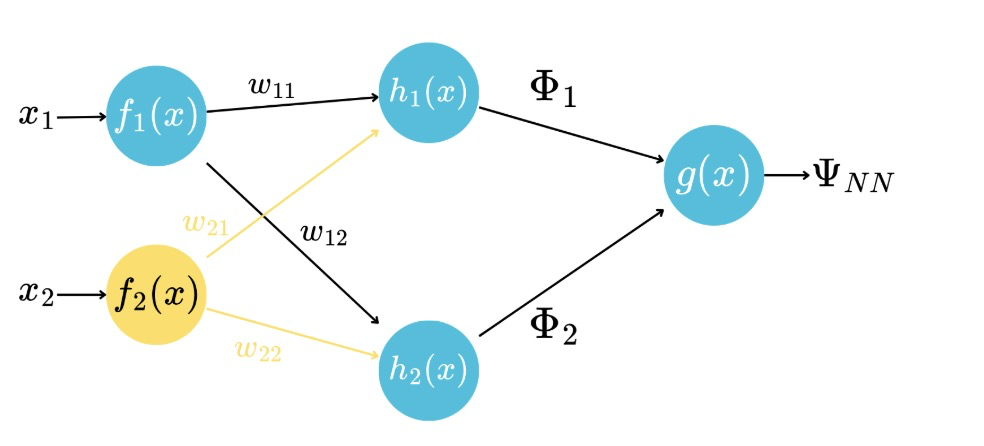

Ah, good question! Both `np.insert` and `np.hstack` can **add a bias column**, but they work slightly differently, and in practice, `np.hstack` is often **simpler and faster**. Let me explain carefully.

---

### 1️⃣ `np.insert`

```python
X_with_bias = np.insert(X, 0, bias, axis=1)
```

* Pros: You can insert the bias **at any column position** (not just at the end).

* Cons: `np.insert` is **less efficient**, because it creates a new array and copies all the data internally.

* Example:

```python
X = np.array([[1,2],[3,4]])
np.insert(X, 0, 1, axis=1)
# Output:
# [[1 1 2]
#  [1 3 4]]
```

* Notice the bias was inserted at column 0.

---

### 2️⃣ `np.hstack`

```python
X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])
```

* Pros: Simple and **efficient** for adding columns to the **end** of an array.
* `np.ones((X.shape[0], 1))` creates a column of 1s (bias).
* Example:

```python
X = np.array([[1,2],[3,4]])
X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])
# Output:
# [[1 2 1]
#  [3 4 1]]
```

* Bias column is added at the **end**, which is fine for most neural network implementations.

* Cons: You **cannot insert in the middle** as easily as `np.insert`.

---

### ✅ Why `hstack` is preferred here

1. Simpler syntax for **appending bias**.
2. Faster for large arrays (avoids copying every time).
3. Works naturally with matrix multiplication if you append bias **last**.

---

If you want, I can **rewrite your XOR network with a bias column using `hstack`** so it can learn correctly. This will fix the main accuracy issue you’re having.

Do you want me to do that?


Ah, I see exactly what you’re asking! Let’s unpack this carefully.

---

### 1️⃣ The weight initialization line

```python
w1 = 2 * np.random.random((n_input_nodes+1, n_hidden_nodes)) - 1
```

* `np.random.random(shape)` generates random numbers **uniformly in [0, 1)**.
* Multiplying by 2 → scales this to **[0, 2)**.
* Subtracting 1 → shifts it to **[-1, 1)**.

So the weights are initialized **randomly between -1 and 1**.

---

### 2️⃣ Why `2 * ... - 1`?

* Neural networks usually work better when weights are **centered around 0**, not all positive.
* This way, the weighted sums going into the activation function can be **positive or negative**, which avoids biasing the neurons too early.
* Example:

```python
np.random.random(5)
# [0.1, 0.5, 0.8, 0.3, 0.9]  (range 0 to 1)

2 * np.random.random(5) - 1
# [-0.8, 0.0, 0.6, -0.4, 0.7]  (range -1 to 1)
```

* This is common in **small networks** like XOR to help **convergence faster**.

---

### 3️⃣ Why not just use `[0, 1)`?

* If weights are all positive, the hidden neurons might all **activate in the same direction**, which can **slow learning** or even prevent learning for functions like XOR.
* Centering weights around 0 gives the network a **better chance to explore the solution space**.

---

If you want, I can **explain why you also add +1 for the bias dimension** and how it affects `w2` as well—this is where many people get confused.

Do you want me to go over that too?


Exactly! Let’s go **step by step** so it’s crystal clear why that works.

---

### 1️⃣ Backpropagation recap

* The idea: compute the **gradient of the loss w.r.t. each layer’s weights**.
* You start from the **output layer** and propagate errors **backwards**.

---

### 2️⃣ Output layer delta

```python
layer2_delta = error * activation_function(layer2_input, deriv=True)
```

* `layer2_delta` represents **how much the output layer neurons “contributed” to the error**.
* Shape: `(n_samples, n_output_nodes)`

---

### 3️⃣ Hidden layer delta

```python
layer1_delta = layer2_delta @ (w2.T) * activation_function(layer1_b, deriv=True)
```

* **Step A:** `layer2_delta @ w2.T`

  * This computes how the **error from the output layer affects each hidden neuron**.
  * Intuition: if a hidden neuron is strongly connected to a “wrong” output neuron, it should be adjusted more.
  * Dimensions: `(n_samples, n_output_nodes) @ (n_output_nodes, n_hidden_nodes+1) = (n_samples, n_hidden_nodes+1)`

* **Step B:** multiply element-wise by `activation_function(layer1_b, deriv=True)`

  * This applies the **derivative of the activation function** at the hidden layer.
  * Why? Because in the chain rule, the gradient w.r.t. the weighted input includes the derivative of the activation:


$$\delta^{(l)} = (\delta^{(l+1)} \cdot W^{(l+1)^T}) \odot f'(z^{(l)})$$

* ✅ So yes: **we “use” layer2_delta** to compute layer1_delta because the error at hidden neurons depends on **how much they influenced the next layer’s error**.

---

### 4️⃣ Intuition

* Think of it like a chain:

  * Output error → backpropagates through weights → tells hidden neurons **how responsible they were for the output error** → multiply by derivative of activation to scale properly.

---

If you want, I can **draw a tiny diagram showing the error flowing from output → hidden → input**, so you can see exactly why `layer2_delta` is enough to compute `layer1_delta`.

Do you want me to do that?


Exactly! Let’s clarify the **layer indexing in backpropagation**, because it can be confusing.

---

### 1️⃣ Standard notation

* Let (l) be the **current layer** you are computing deltas for.

* Then:

  * (a^{(l)}) → activations **of the current layer**
  * (z^{(l)}) → weighted input to layer (l) (before activation)
  * (W^{(l)}) → weights **connecting layer (l-1) → layer (l)**

* The **previous layer** is always (l-1).

---

### 2️⃣ Backpropagation formula

For hidden layers:

[
\delta^{(l)} = (\delta^{(l+1)} \cdot W^{(l+1)^T}) \odot f'(z^{(l)})
]

* `delta^(l)` → error for **current layer l**
* `delta^(l+1)` → error from **next layer**
* Multiply by `W^(l+1).T` to **propagate the next layer’s error backward**
* Multiply element-wise by derivative of activation for **layer l**

---

### 3️⃣ How it applies to your code

```python
layer2_delta = error * activation_function(layer2_input, deriv=True)
layer1_delta = layer2_delta @ (w2.T) * activation_function(layer1_b, deriv=True)
```

* `layer2_delta` → δ^(2) for **output layer**
* `layer1_delta` → δ^(1) for **hidden layer**

  * Computed from δ^(2) (next layer) and W2 (weights from layer1 → layer2)
* Previous layer (`l-1`) is **the input layer X or layer0**

✅ So yes: when you are at **layer 1**, the previous layer is `l-1` = **layer0/input layer**.

---

If you want, I can make a **tiny diagram showing layer0 → layer1 → layer2 with deltas flowing backwards**, which makes the indexing very intuitive.

Do you want me to do that?


In [6]:
gamma1 = 0.01
gamma2 = 0.01

# like you only actually give 2 inputs
n_input_nodes = 2
# there are two hidden nodes
n_hidden_nodes = 2
# you only output once
n_output_nodes = 1

# you add a bias
X_hidden = np.hstack([X, np.ones((X.shape[0], 1))])

y = np.array([[0, 1, 1, 1]]).T

# initialize weights
# there is a plus one for the bias
# basically going from layer 1 to layer 2
# basically W
w1 = 2 * np.random.random((n_input_nodes+1, n_hidden_nodes)) - 1

# this is hidden (plus bias) to output
# basically phi
w2 = 2* np.random.random((n_hidden_nodes + 1, n_output_nodes)) - 1

# train the network
for epoch in range(num_epochs):
    layer0 = X_hidden
    layer1_input = np.dot(layer0, w1)
    layer1 = activation_function(layer1_input)
    # add the bias
    layer1_b = np.hstack([layer1, np.ones((layer1.shape[0], 1))])

    layer2_input = np.dot(layer1_b, w2)
    layer2 = activation_function(layer2_input)

    error = layer2 - y
    if epoch % 10000 == 0:
        print(f"Iter {epoch} --- Error: {np.mean(np.abs(error)):.2f}")
        layer2_delta = error * activation_function(layer2_input, deriv=True)
        layer1_delta = layer2_delta @ (w2.T) * activation_function(layer1_b, deriv=True)
        layer1_delta = layer1_delta[:, :-1]

    # layer1_b.T has shape (n_hidden_nodes+1, n_samples)
    # output_delta has shape (n_samples, n_output_nodes)
    # Dot product will have (n_hidden_nodes+1, n_output_nodes), so exactly the shape of w2
    # also the change of the error wrt to w2 is just input to the layer tranpose times delta of the next layer
    w2 -= gamma2 * layer1_b.T.dot(layer2_delta)
    w1 -= gamma1 * layer0.T.dot(layer1_delta)

Iter 0 --- Error: 0.41


## To actually make the predictions

In [7]:
def forward(X, w1, w2):
    X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])

    input_to_hidden = X_with_bias @ w1

    hidden = activation_function(input_to_hidden)
    hidden_with_bias = np.hstack([hidden, np.ones((hidden.shape[0], 1))])

    hidden_to_out = hidden_with_bias @ w2

    return activation_function(hidden_to_out)

def predict(X, w1, w2, thresh=0.5):
    output_prob = forward(X, w1, w2)
    return np.rint(output_prob).flatten()

In [8]:
# Example

X = np.array(
    [
        [1, -1],
        [-1, 1],
        [1, -1],
        [1, 1]
    ]
)

y_true = np.array([[1, 1, 1, 1]]).T

preds = predict(X, w1, w2)
print(f"Accuracy: {accuracy_score(y_true, y_preds) * 100:.2f}%")

Accuracy: 0.00%


# Part 2 - Two/More Outputs